In [1]:
import matplotlib.pyplot as plt 
import xarray as xr 
import numpy as np 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from adjustText import adjust_text

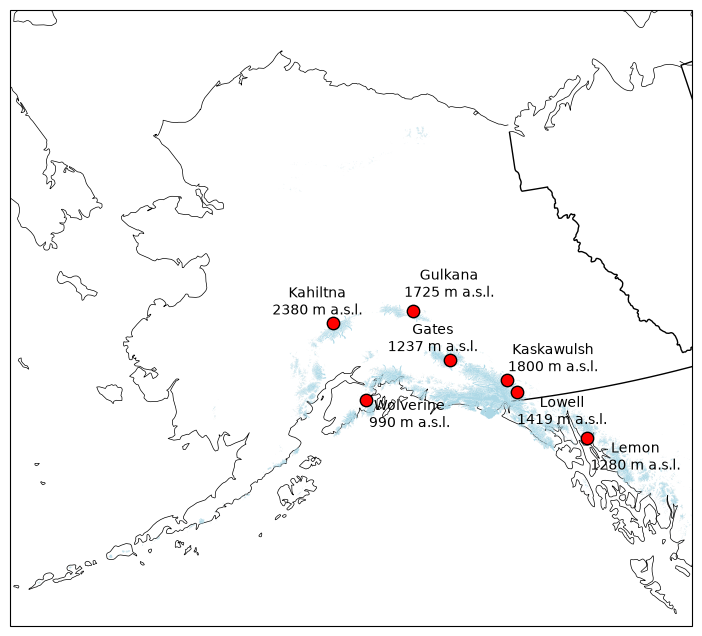

In [5]:
ds = xr.open_dataset('../../data/quantile_cdfs.nc', group='temp')

fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-150, central_latitude=60)}
)

# Pull Alaska state border from Natural Earth (states/provinces)
states = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none'
)
ax.add_feature(states, edgecolor='black')
ax.coastlines('50m', color='black', linewidth=0.5)

# Plot stations — transform=PlateCarree since lon/lat are geographic
ax.scatter(
    ds.lon.values, ds.lat.values,
    transform=ccrs.PlateCarree(),
    s=80, c='red', edgecolor='black', zorder=5
)

map_crs = ax.projection 
ax.set_extent([-170, -130, 52, 72], crs=ccrs.PlateCarree())

# Transform geographic coords -> projected map coords
xs, ys = [], []
for lon, lat in zip(ds.lon.values, ds.lat.values):
    x, y = map_crs.transform_point(lon, lat, ccrs.PlateCarree())
    xs.append(x)
    ys.append(y)
texts = []
for x, y, name, elev in zip(xs, ys, ds.station.values, ds.elevation.values):
    name_crop = name.split('_')[0].capitalize()
    texts.append(
        ax.text(
            x, y,
            f'{name_crop}\n{elev:.0f} m a.s.l.',
            fontsize=10,
            ha='center', va='center',
            zorder=6,
            # bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7),
        )
    )

adjust_text(
    texts,
    x=xs, y=ys,            # the anchor points to avoid
    ax=ax,
    # arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
)

# RGI gdf
gdf = gpd.read_file('/Users/cvw/local/RGI/rgi60/01_rgi60_Alaska/01_rgi60_Alaska.shp')

map_crs = ccrs.LambertConformal(central_longitude=-150, central_latitude=60)
gdf_proj = gdf.to_crs(map_crs.proj4_init)

ax.add_geometries(
    gdf_proj.geometry,
    crs=map_crs,
    facecolor='lightblue',
    edgecolor='none',
    zorder=3
)

plt.show()